In [1]:
num_particles = 1_000
run_time_days = 20
time_step_minutes = 20
out_put_step_hours = 6

#initial position
lon0 = -50
lon1 = -48
lat0 = 1
lat1 = 0.5

depth_min = 1 #todo: figure near-surface depths 
depth_max = 10

start_time = "2022-06-01T00:00:00"

#reproducibility
rdm_seed = 1234

#paths
pathUV= '/work/bk1450/b383184/Amazon/Atlantic/data/UV'
pathW= '/work/bk1450/b383184/Amazon/Atlantic/data/W'
out_path = '../data/tracks/' #path to store the particle zarr

In [2]:
# Parameters
start_time = "2023-02-01T00:00:00"
num_particles = 100000
run_time_days = 185


## Particles from the Plume to the Atlantic

* Release particles from the plume every month (1st day) for 2 years (2022-2025)
* Release time 2022 to 2025
* Number of particles =  100_000
* Release depth = (0,10)
* Compare the Wc and W

In [3]:
from parcels import ParticleSet
from parcels import JITParticle
from parcels import AdvectionRK4_3D
from parcels import AdvectionRK4
from parcels import Variable
from datetime import timedelta
import numpy as np
from parcels import FieldSet
from glob import glob

In [4]:
np.random.seed(rdm_seed)

### Copernicus Data A grid

In [5]:
ufiles = sorted(glob(f"{pathUV}/U_20*.nc"))
vfiles = sorted(glob(f"{pathUV}/V_20*.nc"))
wfiles = sorted(glob(f"{pathW}/W_20*.nc"))

In [6]:
print(ufiles)

['/work/bk1450/b383184/Amazon/Atlantic/data/UV/U_2022_06_m.nc', '/work/bk1450/b383184/Amazon/Atlantic/data/UV/U_2022_07_m.nc', '/work/bk1450/b383184/Amazon/Atlantic/data/UV/U_2022_08_m.nc', '/work/bk1450/b383184/Amazon/Atlantic/data/UV/U_2022_09_m.nc', '/work/bk1450/b383184/Amazon/Atlantic/data/UV/U_2022_10_m.nc', '/work/bk1450/b383184/Amazon/Atlantic/data/UV/U_2022_11_m.nc', '/work/bk1450/b383184/Amazon/Atlantic/data/UV/U_2022_12_m.nc', '/work/bk1450/b383184/Amazon/Atlantic/data/UV/U_2023_01_m.nc', '/work/bk1450/b383184/Amazon/Atlantic/data/UV/U_2023_02_m.nc', '/work/bk1450/b383184/Amazon/Atlantic/data/UV/U_2023_03_m.nc', '/work/bk1450/b383184/Amazon/Atlantic/data/UV/U_2023_04_m.nc', '/work/bk1450/b383184/Amazon/Atlantic/data/UV/U_2023_05_m.nc', '/work/bk1450/b383184/Amazon/Atlantic/data/UV/U_2023_06_m.nc', '/work/bk1450/b383184/Amazon/Atlantic/data/UV/U_2023_07_m.nc', '/work/bk1450/b383184/Amazon/Atlantic/data/UV/U_2023_08_m.nc', '/work/bk1450/b383184/Amazon/Atlantic/data/UV/U_2023_0

In [7]:
## define the fieldset
filenames = {"U": ufiles,
             "V": vfiles,
             "W": wfiles,
            }

variables = {"U": "uo",
             "V": "vo",
             "W": "wo",}

dimensions={'lon':'longitude',
            'lat':'latitude',
            'time':'time',
            'depth': "depth"}


## now the fieldset
fieldset = FieldSet.from_netcdf(
    filenames,
    variables,
    dimensions,
)

In [8]:
start_pos_along_line = np.random.uniform(0,1,size=num_particles)
start_lon = lon0 + start_pos_along_line * (lon1-lon0)
start_lat = lat0 + start_pos_along_line * (lat1-lat0)
start_depth = np.random.uniform(depth_min,depth_max,size=num_particles)
start_times = np.datetime64(start_time)

In [9]:
# initiate pset
pset = ParticleSet(
    fieldset=fieldset,
    lon = start_lon,
    lat = start_lat,
    depth=start_depth,
    time=start_times
) 


out_fn = f'Parcels_run_{rdm_seed}_{start_time}.zarr'

output_file = pset.ParticleFile(
    name=out_path+out_fn,
    outputdt=timedelta(hours=out_put_step_hours),
    chunks = (num_particles,int(run_time_days*24/out_put_step_hours/4))
)

In [10]:
##check the error
def CheckError(particle, fieldset, time):
    if particle.state >= 50:  # This captures all Errors
        particle.delete()

In [11]:
## Execute particles
pset.execute(
    [AdvectionRK4_3D,CheckError],
    runtime=timedelta(days=run_time_days),
    dt=timedelta(minutes=time_step_minutes),
    output_file= output_file
)

INFO: Output files are stored in ../data/tracks/Parcels_run_1234_2023-02-01T00:00:00.zarr.


  0%|                                                                                             | 0/15984000.0 [00:00<?, ?it/s]

  0%|                                                                             | 1200.0/15984000.0 [00:12<44:30:18, 99.76it/s]

  0%|                                                                           | 21600.0/15984000.0 [00:15<2:29:15, 1782.31it/s]

  0%|                                                                           | 22800.0/15984000.0 [00:17<2:51:53, 1547.61it/s]

...

100%|███████████████████████████████████████████████████████████████████████▊| 15942000.0/15984000.0 [1:23:38<00:12, 3350.43it/s]

100%|███████████████████████████████████████████████████████████████████████▉| 15962400.0/15984000.0 [1:23:42<00:05, 4220.01it/s]

100%|███████████████████████████████████████████████████████████████████████▉| 15963600.0/15984000.0 [1:23:44<00:05, 3438.19it/s]

100%|████████████████████████████████████████████████████████████████████████| 15984000.0/15984000.0 [1:23:48<00:00, 4237.65it/s]

100%|████████████████████████████████████████████████████████████████████████| 15984000.0/15984000.0 [1:23:48<00:00, 3178.99it/s]

### Plotting

In [12]:
import xarray as xr

In [13]:
out_path = '../data/tracks/'
# out_fn = 'Parcels_run_692' 

ds_traj = xr.open_zarr(out_path+out_fn)
# ds_traj = ds_traj.compute()
ds_traj

<xarray.Dataset> Size: 2GB
Dimensions:     (trajectory: 100000, obs: 925)
Coordinates:
  * obs         (obs) int32 4kB 0 1 2 3 4 5 6 7 ... 918 919 920 921 922 923 924
  * trajectory  (trajectory) int64 800kB 0 1 2 3 4 ... 99996 99997 99998 99999
Data variables:
    lat         (trajectory, obs) float32 370MB dask.array<chunksize=(100000, 185), meta=np.ndarray>
    lon         (trajectory, obs) float32 370MB dask.array<chunksize=(100000, 185), meta=np.ndarray>
    time        (trajectory, obs) datetime64[ns] 740MB dask.array<chunksize=(100000, 185), meta=np.ndarray>
    z           (trajectory, obs) float32 370MB dask.array<chunksize=(100000, 185), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        JITParticleAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

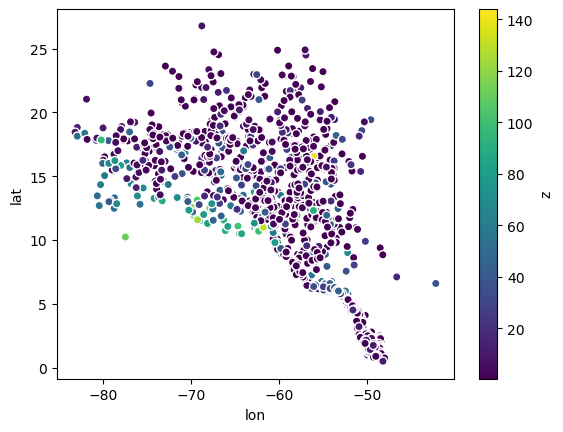

In [14]:
last_valid = ds_traj.lat.notnull().astype(int).diff('obs',label='lower')==-1
ds_traj.where(last_valid).mean('obs').compute().plot.scatter(x='lon',y='lat',hue='z')

In [15]:
ds_traj.lat.isnull().sum('trajectory').rename('Num_invalid').plot()